# The Covid-19 Small Dataset

## Import Libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## EDA

In [3]:
df = pd.read_csv('data/covid.csv', engine='pyarrow')

In [5]:
df

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,None,Afghanistan,1939,60,252
1,4/29/2020,None,Albania,766,30,455
2,4/29/2020,None,Algeria,3848,444,1702
3,4/29/2020,None,Andorra,743,42,423
4,4/29/2020,None,Angola,27,2,7
...,...,...,...,...,...,...
316,4/29/2020,Wyoming,US,545,7,0
317,4/29/2020,Xinjiang,Mainland China,76,3,73
318,4/29/2020,Yukon,Canada,11,0,0
319,4/29/2020,Yunnan,Mainland China,185,2,181


In [7]:
df.count()

Date         321
State        140
Region       321
Confirmed    321
Deaths       321
Recovered    321
dtype: int64

In [8]:
df.shape

(321, 6)

In [9]:
df.size

1926

In [10]:
df.isnull().sum()

Date           0
State        181
Region         0
Confirmed      0
Deaths         0
Recovered      0
dtype: int64

<Axes: >

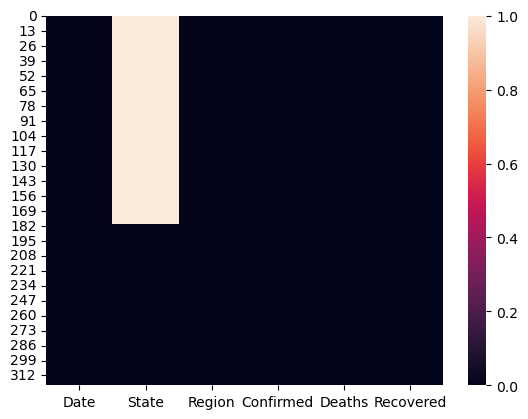

In [12]:
sns.heatmap(df.isnull())

## Tasks

### Show the number of Confirmed, Deaths and Recovered cases in each Region.

In [20]:
df.groupby('Region').sum(numeric_only=True).head(5)

,Confirmed,Deaths,Recovered
Region,,,
Afghanistan,1939,60,252
Albania,766,30,455
Algeria,3848,444,1702
Andorra,743,42,423
Angola,27,2,7


In [24]:
df.groupby('Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

Region
US                1039909
Spain              236899
Italy              203591
France             166543
UK                 166441
Germany            161539
Turkey             117589
Russia              99399
Iran                93657
Mainland China      82862
Name: Confirmed, dtype: int64

In [31]:
df.groupby(['Region']).agg({'Confirmed': 'sum', 'Recovered': 'sum'})

,Confirmed,Recovered
Region,,
Afghanistan,1939,252
Albania,766,455
Algeria,3848,1702
Andorra,743,423
Angola,27,7
...,...,...
West Bank and Gaza,344,71
Western Sahara,6,5
Yemen,6,1


### Remove all the records where the Confirmed Cases is Less Than 10.

In [32]:
df.head()

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,None,Afghanistan,1939,60,252
1,4/29/2020,None,Albania,766,30,455
2,4/29/2020,None,Algeria,3848,444,1702
3,4/29/2020,None,Andorra,743,42,423
4,4/29/2020,None,Angola,27,2,7


In [39]:
df['Confirmed'] < 10

0      False
1      False
2      False
3      False
4      False
       ...  
316    False
317    False
318    False
319    False
320    False
Name: Confirmed, Length: 304, dtype: bool

In [40]:
df[~(df['Confirmed'] < 10)]

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,None,Afghanistan,1939,60,252
1,4/29/2020,None,Albania,766,30,455
2,4/29/2020,None,Algeria,3848,444,1702
3,4/29/2020,None,Andorra,743,42,423
4,4/29/2020,None,Angola,27,2,7
...,...,...,...,...,...,...
316,4/29/2020,Wyoming,US,545,7,0
317,4/29/2020,Xinjiang,Mainland China,76,3,73
318,4/29/2020,Yukon,Canada,11,0,0
319,4/29/2020,Yunnan,Mainland China,185,2,181


In [37]:
df = df[~(df['Confirmed'] < 10)]

In [38]:
df

,Date,State,Region,Confirmed,Deaths,Recovered
0,4/29/2020,None,Afghanistan,1939,60,252
1,4/29/2020,None,Albania,766,30,455
2,4/29/2020,None,Algeria,3848,444,1702
3,4/29/2020,None,Andorra,743,42,423
4,4/29/2020,None,Angola,27,2,7
...,...,...,...,...,...,...
316,4/29/2020,Wyoming,US,545,7,0
317,4/29/2020,Xinjiang,Mainland China,76,3,73
318,4/29/2020,Yukon,Canada,11,0,0
319,4/29/2020,Yunnan,Mainland China,185,2,181


### In which Region, maximum number of Confirmed cases were recorded?

In [45]:
df.groupby('Region').Confirmed.sum().sort_values(ascending=False).head(20)

Region
US                1039909
Spain              236899
Italy              203591
France             166536
UK                 166432
Germany            161539
Turkey             117589
Russia              99399
Iran                93657
Mainland China      82861
Brazil              79685
Canada              52860
Belgium             47859
Netherlands         38993
Peru                33931
India               33062
Switzerland         29407
Ecuador             24675
Portugal            24505
Saudi Arabia        21402
Name: Confirmed, dtype: int64

### In which Region, minimum number of Deaths cases were recorded?

In [51]:
df.groupby('Region').Deaths.sum().sort_values(ascending=True).head(50)

Region
Cambodia                            0
Seychelles                          0
Saint Lucia                         0
Central African Republic            0
Saint Kitts and Nevis               0
South Sudan                         0
Rwanda                              0
Grenada                             0
Macau                               0
Madagascar                          0
Nepal                               0
Namibia                             0
Saint Vincent and the Grenadines    0
Mozambique                          0
Holy See                            0
Timor-Leste                         0
Mongolia                            0
Uganda                              0
Laos                                0
Eritrea                             0
Vietnam                             0
Fiji                                0
Dominica                            0
Gambia                              1
Equatorial Guinea                   1
Eswatini                            1
Cabo 

### How many Confirmed, Deaths & Recovered cases were reported from India till 29 April 2020?

In [52]:
df[df['Region'] == 'India']

,Date,State,Region,Confirmed,Deaths,Recovered
74,4/29/2020,None,India,33062,1079,8437


In [53]:
df[df['Region'] == 'US']

,Date,State,Region,Confirmed,Deaths,Recovered
181,4/29/2020,Alabama,US,6912,256,0
182,4/29/2020,Alaska,US,355,9,0
186,4/29/2020,Arizona,US,7209,308,0
187,4/29/2020,Arkansas,US,3193,57,0
195,4/29/2020,California,US,48747,1946,0
199,4/29/2020,Colorado,US,14758,766,0
200,4/29/2020,Connecticut,US,26767,2169,0
202,4/29/2020,Delaware,US,4655,144,0
204,4/29/2020,Diamond Princess cruise ship,US,49,0,0
205,4/29/2020,District of Columbia,US,4106,205,0


### Sort the entire data wrt No. of Confirmed cases in ascending order.

In [55]:
df.sort_values(by=['Confirmed'], ascending=True)

,Date,State,Region,Confirmed,Deaths,Recovered
156,4/29/2020,None,Suriname,10,1,8
70,4/29/2020,None,Holy See,10,0,2
59,4/29/2020,None,Gambia,10,1,8
318,4/29/2020,Yukon,Canada,11,0,0
217,4/29/2020,Greenland,Denmark,11,0,11
...,...,...,...,...,...,...
57,4/29/2020,None,France,165093,24087,48228
168,4/29/2020,None,UK,165221,26097,0
80,4/29/2020,None,Italy,203591,27682,71252
153,4/29/2020,None,Spain,236899,24275,132929


### Sort the entire data wrt No. of Recovered cases in descending order.

In [56]:
df.sort_values(by= ['Recovered'], ascending=True)

,Date,State,Region,Confirmed,Deaths,Recovered
199,4/29/2020,Colorado,US,14758,766,0
276,4/29/2020,Ontario,Canada,16978,1153,0
116,4/29/2020,None,Netherlands,38802,4711,0
246,4/29/2020,Manitoba,Canada,275,6,0
277,4/29/2020,Oregon,US,2446,101,0
...,...,...,...,...,...,...
229,4/29/2020,Hubei,Mainland China,68128,4512,63616
80,4/29/2020,None,Italy,203591,27682,71252
76,4/29/2020,None,Iran,93657,5957,73791
61,4/29/2020,None,Germany,161539,6467,120400
